# Bài tập Buổi 6 — Cây Quyết Định & Rừng Ngẫu Nhiên (Decision Tree & Random Forest)

**Sinh viên thực hiện:** Phạm Trường Quốc Huy 

---

## Bối cảnh

Trong bài tập này, bạn đang đóng vai trò là một Data Scientist làm việc tại một trung tâm nghiên cứu ung thư. Bạn được giao nhiệm vụ phân tích bộ dữ liệu **Breast Cancer Wisconsin (Diagnostic)**, chứa các thông số đo lường từ hình ảnh sinh thiết tế bào của các bệnh nhân.

Mục tiêu của bài toán là xây dựng mô hình học máy để phân loại khối u là **Lành tính (Benign)** hay **Ác tính (Malignant)**.

**Lưu ý quan trọng:** Trong bài toán chẩn đoán ung thư, việc chẩn đoán sót một khối u ác tính thành lành tính (False Negative) mang lại hậu quả nghiêm trọng hơn rất nhiều so với việc chẩn đoán nhầm lành tính thành ác tính (False Positive). Do đó, chúng ta sẽ đặc biệt quan tâm đến chỉ số **Recall**.

## Mục tiêu bài tập

1. Hiểu và xử lý bộ dữ liệu y khoa cơ bản với nhiều đặc trưng dạng số liên tục.
2. Huấn luyện mô hình **Decision Tree** và trực quan hóa các ranh giới quyết định (Decision Boundaries) thông qua cấu trúc cây.
3. Xây dựng mô hình **Random Forest** và đánh giá độ quan trọng của các đặc trưng (Feature Importance) trong việc chẩn đoán.
4. Phân tích chuyên sâu về các độ đo **Recall, F1-Score** và **Confusion Matrix** thay vì chỉ phụ thuộc vào Accuracy.

## Tiêu chí chấm (10 điểm)

| Task | Nội dung | Điểm |
|---|---|---|
| **1** | EDA & Thống kê dữ liệu tổng quan | 1.0 |
| **2** | Trực quan hóa tương quan dữ liệu | 2.0 |
| **3** | Chia tập & Scaling | 1.0 |
| **4** | Huấn luyện Decision Tree & Trực quan hóa cây | 2.0 |
| **5** | Huấn luyện Random Forest & Feature Importance | 2.0 |
| **6** | Đánh giá Confusion Matrix, Recall, F1-score và rút ra Insight | 2.0 |

---


## 0. Chuẩn bị môi trường & Nạp dữ liệu

Dữ liệu được tích hợp sẵn trong thư viện `scikit-learn`. Chạy ô bên dưới để tải và hiển thị.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, recall_score, f1_score

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)

# Tải dữ liệu Breast Cancer
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target

print("Kích thước bộ dữ liệu:", df.shape)
print("Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):")
print(dict(zip(range(len(cancer_data.target_names)), cancer_data.target_names)))
df.head()

Kích thước bộ dữ liệu: (569, 31)
Ý nghĩa Target (0: Malignant/Ác tính, 1: Benign/Lành tính):
{0: np.str_('malignant'), 1: np.str_('benign')}


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


---
## Task 1 — EDA và Kiểm tra Dữ liệu Cơ Bản

### Yêu cầu:
1. In ra số lượng mẫu dữ liệu cho từng lớp (0: Ác tính, 1: Lành tính) bằng `value_counts()`.
2. Kiểm tra xem dữ liệu có giá trị khuyết thiếu (NaN) nào không.
3. Nêu nhận xét về sự cân bằng của bộ dữ liệu.

### Gợi ý:
- Sử dụng cú pháp `df['tên_cột'].value_counts()` để đếm số lượng nhãn.
- Để kiểm tra missing value trên toàn bộ dataframe, bạn có thể kết hợp `.isnull().sum()`.

In [2]:
# TODO 1a: Đếm số lượng mẫu của từng class trong cột 'target'
print(df['target'].value_counts())

# TODO 1b: Kiểm tra giá trị missing
print(df.isnull().sum())

target
1    357
0    212
Name: count, dtype: int64
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


**Nhận xét Task 1:**
- Dữ liệu hơi mất cân bằng nhẹ giữa 2 nhãn (nhãn 1 -  62.7%; nhãn 2 -  37.3%)
- Dữ liệu hoàn toàn sạch, không có số liệu bị khuyết

---
## Task 2 — Trực quan hóa Dữ liệu Y khoa

Bộ dữ liệu có tới 30 đặc trưng, chúng ta sẽ khảo sát một vài đặc trưng cơ bản.

### Yêu cầu:
1. Vẽ biểu đồ **Boxplot** so sánh phân phối của biến `mean radius` (bán kính trung bình của tế bào) giữa 2 lớp Khối u (Ác tính và Lành tính).
2. Vẽ biểu đồ **Scatter plot** giữa `mean radius` (trục x) và `mean texture` (trục y), tô màu (hue) theo cột `target`.
3. Có thể dùng 2 đặc trưng này để phân định ranh giới cơ bản giữa khối u lành/ác được không? Vì sao?

### Gợi ý:
- Vẽ Boxplot: `sns.boxplot(data=df, x='target', y='mean radius')`.
- Vẽ Scatter plot: `sns.scatterplot(data=df, x='mean radius', y='mean texture', hue='target')`.

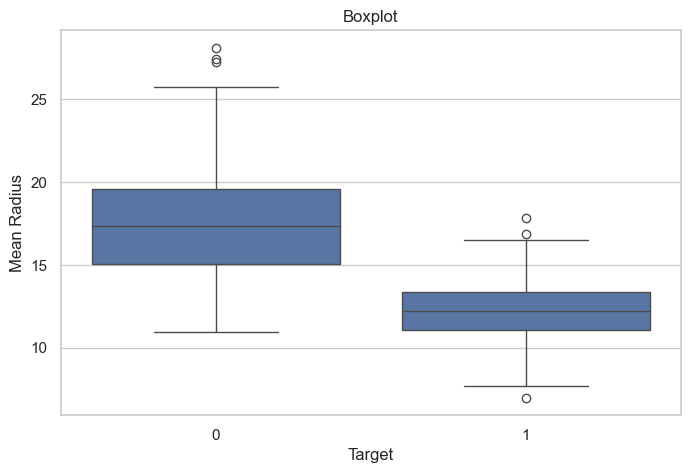

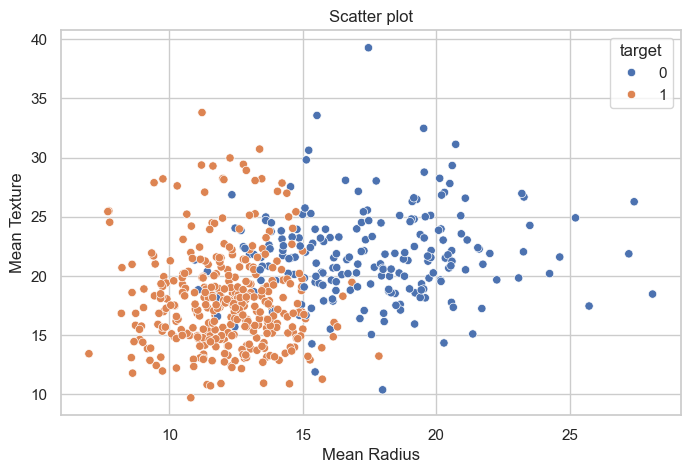

In [3]:
# TODO 2a: Boxplot cho biến 'mean radius' so với 'target'
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="target", y="mean radius")
plt.title("Boxplot")
plt.xlabel("Target")
plt.ylabel("Mean Radius")
plt.show()

# TODO 2b: Scatter plot giữa 'mean radius' và 'mean texture'
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="mean radius", y="mean texture", hue="target")
plt.title("Scatter plot")
plt.xlabel("Mean Radius")
plt.ylabel("Mean Texture")
plt.show()

**Nhận xét Task 2:**
- Dựa vào Boxplot thì có thể thấy rằng 2 lớp hoàn toàn tách biệt nhau, khoảng tứ phân vị không bị chồng lấp. Trung vị lệch nhau rõ
- U lành tính tập trung thành cụm dày đặc ở vùng góc phải dưới, u ác tính thì phân tán rộng hơn về phía góc trên phải
- Tồn tại vùng giao thoa giữa u lành và u ác tính, nếu dùng siêu phẳng để phân tách thì vẫn có thể bị sót lỗi

---
## Task 3 — Chia Tập Dữ Liệu và Tiền Xử Lý

### Yêu cầu:
1. Tách đặc trưng (X) và nhãn (y).
2. Chia tập Train/Test theo tỷ lệ **75/25**, `stratify=y`, và `random_state=42`.
3. Mặc dù Decision Tree và Random Forest không yêu cầu chuẩn hóa (Scaling), nhưng việc có `StandardScaler` sẽ giúp dễ dàng so sánh với các thuật toán khác (như SVM/Logistic Regression) sau này. Hãy fit `StandardScaler` trên `X_train` và transform cho cả `X_train` và `X_test`.

### Gợi ý:
- Sử dụng hàm `train_test_split(X, y, test_size=0.25, stratify=y, random_state=42)`.
- **Nguyên tắc chống Data Leakage:** Chỉ dùng phương thức `.fit_transform()` trên tập `X_train`, nhưng chỉ được dùng phương thức `.transform()` trên tập `X_test`.

In [4]:
# TODO 3a: Tách X, y và chia train/test
X = df.drop(columns=['target'])
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# TODO 3b: Chuẩn hóa dữ liệu bằng StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

---
## Task 4 — Huấn luyện Cây Quyết Định (Decision Tree)

### Yêu cầu:
1. Khởi tạo và huấn luyện `DecisionTreeClassifier(max_depth=3, random_state=42)` trên tập Train.
2. Sử dụng `plot_tree` để vẽ cấu trúc cây.
3. Nút gốc (Root Node) đang dùng đặc trưng nào để chia nhánh dữ liệu đầu tiên? Bạn có nghĩ đó là đặc trưng quan trọng nhất không?

### Gợi ý:
- Khởi tạo mô hình: `dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)`.
- Đừng quên gọi `.fit(X_train_scaled, y_train)` trước khi thực hiện vẽ sơ đồ cây.

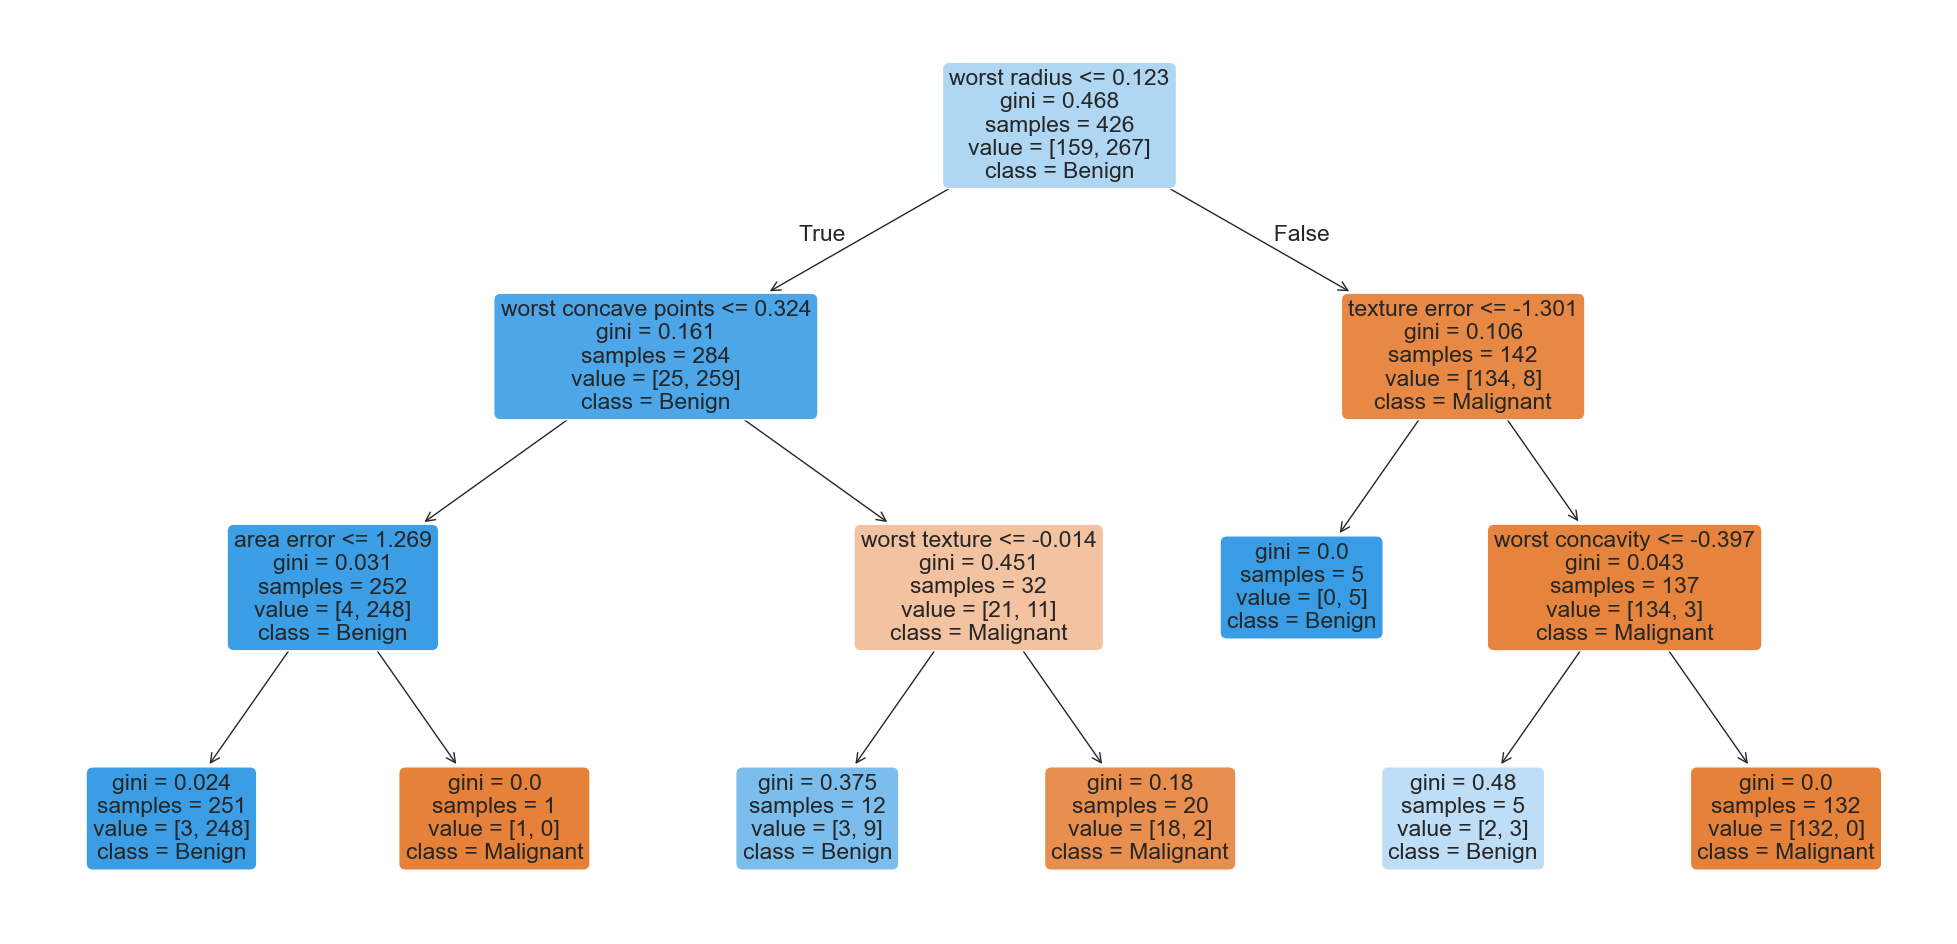

In [5]:
# TODO 4a: Khởi tạo và huấn luyện Decision Tree
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_model.fit(X_train_scaled, y_train)

# TODO 4b: Vẽ cấu trúc Decision Tree
plt.figure(figsize=(25,12))
plot_tree(dt_model, feature_names=cancer_data.feature_names, class_names=['Malignant', 'Benign'], filled=True, rounded=True)
plt.show()

**Nhận xét Task 4:**
- Nút gốc sử dụng đặc trưng `worst radius` với ngưỡng phân chia là 0.123
- Nhánh True tập trung chủ yếu là u lành tính
- Nhánh False tập trung chủ yếu là u ác tính
- Với độ sâu = 3 thì cây đã tạo ra 3 nút lá có độ tinh khiết tuyệt đối, thể hiện khả năng phân lớp cực kì hiệu quả mà chưa quá phức tạp

---
## Task 5 — Rừng Ngẫu Nhiên & Độ Quan Trọng của Đặc Trưng

### Yêu cầu:
1. Khởi tạo và huấn luyện `RandomForestClassifier(n_estimators=100, random_state=42)`.
2. Lấy ra mức độ quan trọng của từng đặc trưng (`feature_importances_`).
3. Vẽ biểu đồ **Bar plot ngang (Horizontal Barplot)** hiển thị **Top 10 đặc trưng quan trọng nhất** theo đánh giá của Random Forest.

### Gợi ý:
- Tạo DataFrame để dễ dàng sắp xếp: `imp_df = pd.DataFrame({'Feature': cancer_data.feature_names, 'Importance': rf_model.feature_importances_})`.
- Sắp xếp giảm dần: `imp_df = imp_df.sort_values(by='Importance', ascending=False)`.
- Lấy 10 dòng đầu (`.head(10)`) và đưa vào hàm `sns.barplot(data=..., x='Importance', y='Feature')` để vẽ.

                 Feature  Importance
23            worst area    0.149674
27  worst concave points    0.127189
7    mean concave points    0.104650
20          worst radius    0.086963
22       worst perimeter    0.080299
2         mean perimeter    0.080037
6         mean concavity    0.055420
0            mean radius    0.053665
3              mean area    0.044062
13            area error    0.024557


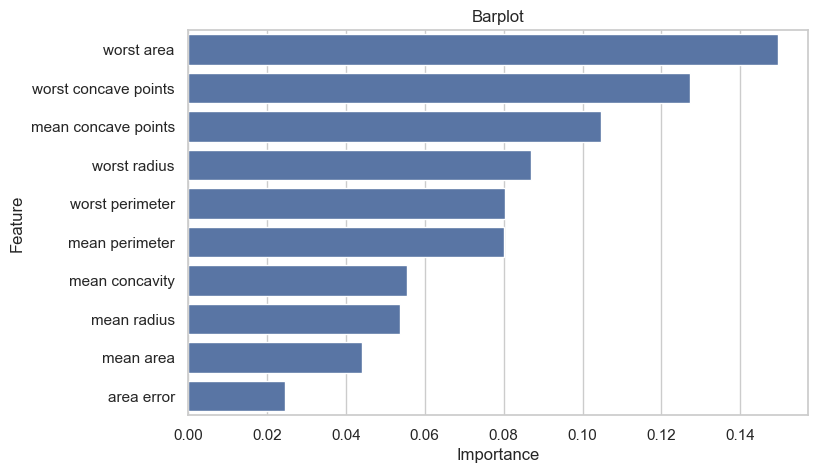

In [6]:
# TODO 5a: Huấn luyện Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# TODO 5b: Trích xuất và trực quan hóa Top 10 Feature Importances
importances = rf_model.feature_importances_
imp_df = pd.DataFrame({'Feature': cancer_data.feature_names, 'Importance': importances})
imp_df = imp_df.sort_values(by='Importance', ascending=False)

top10 = imp_df.head(10)
print(top10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top10, x="Importance", y='Feature')
plt.title("Barplot")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

---
## Task 6 — Đánh giá Mô Hình chuyên sâu (Confusion Matrix, Recall, F1)

Trong bài toán này:
*   **Class 0 (Malignant - Ác tính)** là lớp chúng ta cực kỳ muốn tìm ra.
*   **Class 1 (Benign - Lành tính)** là lớp ít nguy hiểm hơn.

**Recall của lớp 0** cho biết: Trong tổng số những người thực sự mắc bệnh ung thư ác tính, mô hình đã "bắt" được bao nhiêu phần trăm?

### Yêu cầu:
1. Dự đoán trên tập Test bằng mô hình Random Forest ở Task 5.
2. Vẽ **Confusion Matrix**.
3. In `classification_report` và phân tích kết quả của `Recall` và `F1-Score` đặc biệt cho lớp 0 (Malignant).
4. Mô hình hiện tại của bạn đã bỏ sót bao nhiêu bệnh nhân có khối u ác tính trên tập Test (False Negative)? Con số này đã đủ tốt để triển khai thực tế chưa?

### Gợi ý:
- Lệnh dự đoán: `y_pred_rf = rf_model.predict(X_test_scaled)`.
- Dùng hàm `confusion_matrix(y_test, y_pred_rf)` kết hợp với `ConfusionMatrixDisplay` (đã import ở ô đầu tiên) để vẽ.
- Cần cẩn thận khi đọc Confusion Matrix: Dựa vào các trục Thực tế (True label) và Dự đoán (Predicted label), hãy nhìn vào ô có `Thực tế = 0` nhưng `Dự đoán = 1` để tìm số ca bị bỏ sót.

              precision    recall  f1-score   support

           0       0.96      0.92      0.94        53
           1       0.96      0.98      0.97        90

    accuracy                           0.96       143
   macro avg       0.96      0.95      0.95       143
weighted avg       0.96      0.96      0.96       143



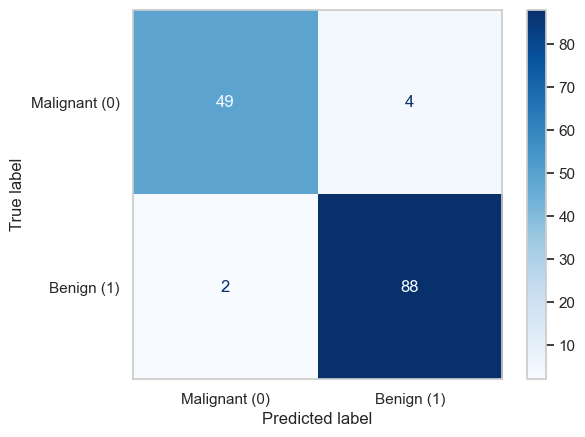

In [7]:
# TODO 6a: Dự đoán trên Test set
y_pred_rf = rf_model.predict(X_test_scaled)

# TODO 6b: In Classification Report
print(classification_report(y_test, y_pred_rf))

# TODO 6c: Vẽ Confusion Matrix
disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf), display_labels=['Malignant (0)', 'Benign (1)'])
disp.plot(cmap='Blues')
plt.grid(False)
plt.show()

**Đánh giá Task 6 (Business/Medical Insight):**

1. Recall của lớp 0: 0.92; F1-score của lớp 0: 0.94
2. Số bệnh nhân bị bỏ sót là 4 ca (~ 7.55%)
3. Góc nhìn y khoa: theo như độ quan trọng đã nói ở lúc đầu, ta thà chấp nhận đánh đổi Precision để tối đa hoá Recall
    - Nếu bệnh nhân có bệnh mà không được chẩn đoán sớm thì sẽ không thể chữa trị kịp thời, dẫn đến nguy cơ tử vong rất cao
    - Để tăng Recall, ta có thể hạ Threshold xuống khoảng 0.2-0.3. Làm vậy có thể khiến Precision giảm nhẹ, nhưng giúp đẩy Recall lên cao, "thà bắt nhầm còn hơn bỏ sót"